# 5.3 — Performing the Experiment with Data Acquisition

**Virtual lab:** *Ultrafast X-Ray Experiments* (Exp21), FXE @ European XFEL.
**Goal:** exercises 22–29 — centre the jet, record the ground-state K$\beta_{1,3}$
spectrum, establish spatial/temporal overlap, take the first transient at
$\Delta t = 100$ ps, and map the pump–probe figure-of-merit against position,
intensity and delay.

This section is **data-driven**: each step consumes something the VLab (or the
online app) exports. The loaders below read those files if present in `data/`
and otherwise fall back to physically-motivated synthetic stand-ins so the
processing can be developed before beamtime. Expected filenames are given
inline; replace the synthetic data by exporting the corresponding VLab traces.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Run from the repository root and import `vlab_xray` from this repository's
# own `src/`, so that `data/` and `figures/` resolve identically no matter
# where Jupyter was started and an editable install of another copy of the
# package cannot shadow these sources.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "src" / "vlab_xray").is_dir())
os.chdir(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from vlab_xray import vlab_utils as V

V.use_paper_style()
os.makedirs("figures", exist_ok=True)

# Energy grid used throughout the emission analysis
E = np.linspace(7020, 7080, 601)
EXC_FRAC = 0.30          # excited-state fraction reached by the pump (~30%)


def on_off_spectra(hs_fraction, energy=E, exc=EXC_FRAC, noise=0.0, seed=0):
    """Build area-normalised laser-off (LS) and laser-on spectra.

    The laser-on spectrum is a mixture (1-x)*LS + x*[state], with x the excited
    fraction and *hs_fraction* selecting the excited-state spin character
    (0 = LS-like, 1 = HS). Returns (off, on)."""
    _, ls = V.Synthetic.kb_spectrum(energy, spin_fraction=0.0, noise=noise, seed=seed)
    _, ex = V.Synthetic.kb_spectrum(energy, spin_fraction=hs_fraction, noise=noise, seed=seed + 1)
    off = V.area_normalize(energy, ls)
    on = V.area_normalize(energy, (1 - exc) * ls + exc * ex)
    return off, on

## Exercise 22 — Centre the liquid jet on the X-ray beam

Maximise the elastic X-ray scattering on the Large Pixel Detector (LPD) while
translating the jet across the beam; the intensity peaks when the jet is
centred. Record the maximum so it can be recovered after each restart.

*Data:* `data/jet_scan.txt` — two columns (jet position [µm], LPD counts).

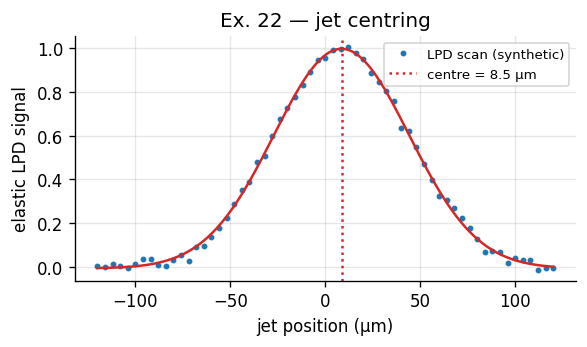

Optimum jet position: 8.5 µm  (record this maximum for re-alignment).


In [2]:
def _jet_scan(seed=0):
    x = np.linspace(-120, 120, 61)
    rng = np.random.default_rng(seed)
    y = V.gaussian(x, 1.0, 8.0, 35.0) + rng.normal(0, 0.02, x.size)
    return x, y

xj, yj, srcj = V.load_1d("jet_scan", gen=_jet_scan)
fitj = V.fit_gaussian(xj, yj)
fig, ax = plt.subplots(figsize=(5.0, 3.0))
ax.plot(xj, yj, ".", ms=5, label=f"LPD scan ({srcj or 'synthetic'})")
xx = np.linspace(xj.min(), xj.max(), 300)
ax.plot(xx, V.gaussian(xx, fitj["amp"], fitj["cen"], fitj["sigma"], fitj["offset"]), "C3")
ax.axvline(fitj["cen"], color="C3", ls=":", label=f"centre = {fitj['cen']:.1f} µm")
ax.set_xlabel("jet position (µm)"); ax.set_ylabel("elastic LPD signal")
ax.set_title("Ex. 22 — jet centring"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig("figures/ex22_jet.png", dpi=150); plt.show()
print(f"Optimum jet position: {fitj['cen']:.1f} µm  (record this maximum for re-alignment).")

## Exercise 23 — Ground-state K$\beta_{1,3}$ spectrum (laser off)

With the von Hamos crystal at the Bragg angle from Ex. 21 and the detector in
the line focus, download the 1-D emission trace and plot the LS ground-state
K$\beta_{1,3}$ spectrum.

*Data:* `data/kb_ground.txt` — (energy [eV], intensity).

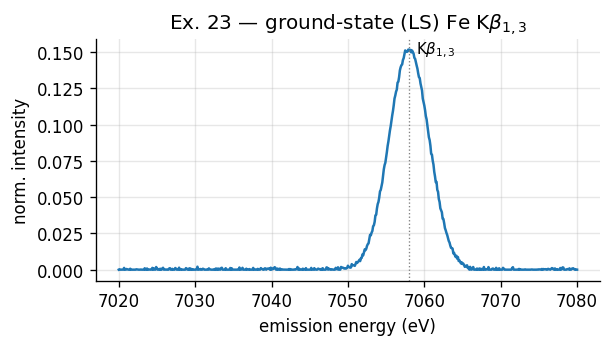

Ground-state Kβ1,3 peak at 7058.0 eV; the weak Kβ' region (~7045 eV) is essentially empty in the singlet ground state.


In [3]:
def _kb_ground():
    return V.Synthetic.kb_spectrum(E, spin_fraction=0.0, noise=0.006, seed=7)

eg, yg, srcg = V.load_1d("kb_ground", gen=_kb_ground)
yg_n = V.area_normalize(eg, np.clip(yg, 0, None))
fig, ax = plt.subplots(figsize=(5.2, 3.0))
ax.plot(eg, yg_n)
ax.axvline(V.FE_KB13_EV, color="grey", ls=":", lw=0.8)
ax.annotate(r"K$\beta_{1,3}$", (V.FE_KB13_EV, yg_n.max()), fontsize=9,
            xytext=(4, -2), textcoords="offset points")
ax.set_xlabel("emission energy (eV)"); ax.set_ylabel("norm. intensity")
ax.set_title("Ex. 23 — ground-state (LS) Fe K$\\beta_{1,3}$")
fig.tight_layout(); fig.savefig("figures/ex23_ground.png", dpi=150); plt.show()
print(f"Ground-state Kβ1,3 peak at {eg[np.argmax(yg_n)]:.1f} eV; the weak Kβ' region "
      f"(~7045 eV) is essentially empty in the singlet ground state.")

## Exercise 24 — Spatial overlap of pump and probe

Focus the pump (Ex. 18) and overlap it with the X-ray focus by translating the
focusing lens in x and y. Document both beams with the X-ray microscope
(attenuate the X-rays to image the laser alone; set the laser to zero to image
the X-rays alone; then image both).

*Data:* `data/xray_on_laser_off.npy`, `data/xray_off_laser_on.npy`.

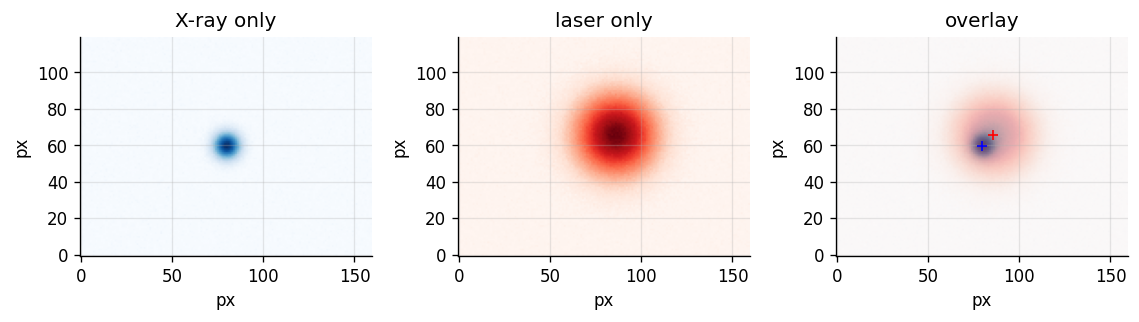

Centroid offset (probe→pump): Δx = 6.0 px, Δy = 5.9 px → move the focusing lens to null this before recording transients.


In [4]:
xray_img, _ = V.load_image(
    "xray_on_laser_off",
    gen=lambda: V.Synthetic.beam_image(fwhm_px=(12, 12), center=(80, 60), noise=0.01, seed=3))
laser_img, _ = V.load_image(
    "xray_off_laser_on",
    gen=lambda: V.Synthetic.beam_image(fwhm_px=(36, 36), center=(86, 66), noise=0.01, seed=4))
fig, axs = plt.subplots(1, 3, figsize=(9.6, 3.0))
axs[0].imshow(xray_img, origin="lower", cmap="Blues"); axs[0].set_title("X-ray only")
axs[1].imshow(laser_img, origin="lower", cmap="Reds"); axs[1].set_title("laser only")
axs[2].imshow(laser_img, origin="lower", cmap="Reds", alpha=0.7)
axs[2].imshow(xray_img, origin="lower", cmap="Blues", alpha=0.5)
axs[2].set_title("overlay")
cx_x, cy_x = V.centroid_2d(xray_img); cx_l, cy_l = V.centroid_2d(laser_img)
axs[2].plot([cx_x], [cy_x], "b+"); axs[2].plot([cx_l], [cy_l], "r+")
for a in axs:
    a.set_xlabel("px"); a.set_ylabel("px")
fig.tight_layout(); fig.savefig("figures/ex24_overlap.png", dpi=150); plt.show()
print(f"Centroid offset (probe→pump): Δx = {(cx_l-cx_x):.1f} px, Δy = {(cy_l-cy_x):.1f} px "
      "→ move the focusing lens to null this before recording transients.")

**Result.** The larger laser footprint overfills the X-ray focus (Ex. 18); the
residual centroid offset is what the lens x/y translation removes. Fine overlap
is then optimised on the pump–probe signal itself (Ex. 26).

## Exercise 25 — First time-resolved spectra at $\Delta t = 100$ ps

At 100 ps the pump surely precedes the probe and the metastable HS state is
fully populated. Record laser-on and laser-off K$\beta_{1,3}$ spectra,
**area-normalise** both, overlay them, then form the difference and describe the
transient.

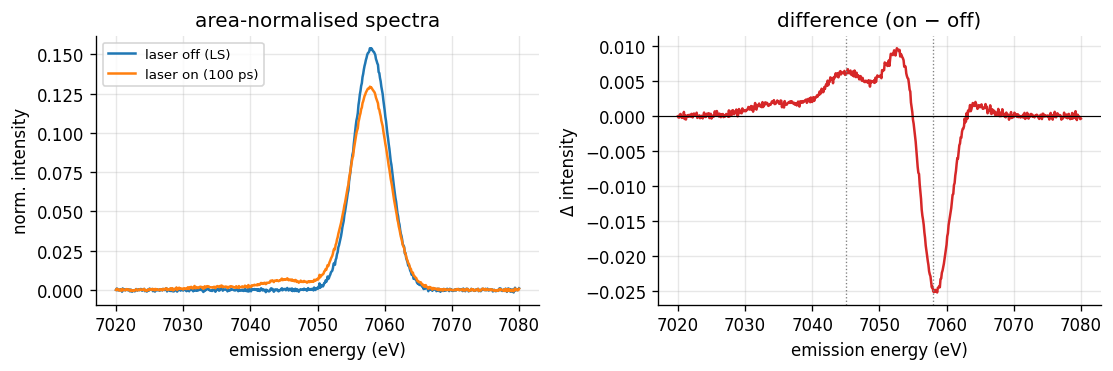

Transient IS recognisable. Difference features:
  • positive gain at the Kβ' satellite (~7045 eV), Δ ≈ +0.0061
  • derivative-like dip/peak at Kβ1,3 (~7058 eV): the main line shifts to lower energy and broadens as the spin state increases (LS→HS).


In [5]:
off, on = on_off_spectra(hs_fraction=1.0, noise=0.004, seed=11)   # 100 ps ⇒ full HS
diff = on - off

fig, axs = plt.subplots(1, 2, figsize=(9.4, 3.2))
axs[0].plot(E, off, label="laser off (LS)")
axs[0].plot(E, on, label="laser on (100 ps)")
axs[0].set_title("area-normalised spectra"); axs[0].legend(fontsize=8)
axs[0].set_xlabel("emission energy (eV)"); axs[0].set_ylabel("norm. intensity")
axs[1].plot(E, diff, "C3"); axs[1].axhline(0, color="k", lw=0.7)
axs[1].axvline(V.FE_KBP_EV, color="grey", ls=":", lw=0.8)
axs[1].axvline(V.FE_KB13_EV, color="grey", ls=":", lw=0.8)
axs[1].set_title("difference (on − off)")
axs[1].set_xlabel("emission energy (eV)"); axs[1].set_ylabel("Δ intensity")
fig.tight_layout(); fig.savefig("figures/ex25_transient100ps.png", dpi=150); plt.show()

kbp_amp = diff[np.argmin(abs(E - V.FE_KBP_EV))]
print(f"Transient IS recognisable. Difference features:")
print(f"  • positive gain at the Kβ' satellite (~7045 eV), Δ ≈ +{kbp_amp:.4f}")
print(f"  • derivative-like dip/peak at Kβ1,3 (~7058 eV): the main line shifts to "
      f"lower energy and broadens as the spin state increases (LS→HS).")

**Result.** The characteristic HS fingerprint appears: the spin-sensitive
K$\beta'$ satellite grows in and the K$\beta_{1,3}$ line red-shifts/broadens —
exactly the LS→HS signature of Fig. 4.3. Quantitative spin-state assignment
follows in Section 5.4.

## Exercise 26 — Optimise spatial overlap on the pump–probe signal

Define a figure of merit (FOM) for the transient strength — here the integrated
absolute difference signal — and map it as the laser is scanned in x and y.

*Data:* `data/fom_xscan.txt`, `data/fom_yscan.txt` (position [µm], FOM).

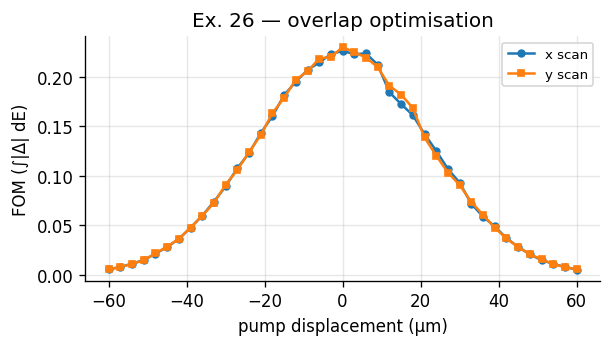

Overlap FOM peaks near zero displacement in both axes → set the lens there. FWHM of the response ≈ 51 µm (set by the beam sizes).


In [6]:
def fom_from_diff(d):
    """FOM = integrated |difference| over the Kβ window (∝ excited fraction)."""
    return np.trapezoid(np.abs(d), E)

FOM_100ps = fom_from_diff(diff)


def _overlap_scan(axis_offset_um, seed=0):
    """FOM vs pump position: peaks at perfect overlap, width set by beam sizes."""
    rng = np.random.default_rng(seed)
    # overlap efficiency ~ Gaussian in displacement (convolution of the two spots)
    eff = np.exp(-0.5 * (axis_offset_um / 22.0) ** 2)
    return FOM_100ps * eff * (1 + rng.normal(0, 0.02, np.shape(axis_offset_um)))

xoff = np.linspace(-60, 60, 41)
try:
    ax_x = np.loadtxt("data/fom_xscan.txt"); fx = ax_x[:, 1]; xoff = ax_x[:, 0]
except OSError:
    fx = _overlap_scan(xoff, seed=1)
try:
    ax_y = np.loadtxt("data/fom_yscan.txt"); fy = ax_y[:, 1]; yoff = ax_y[:, 0]
except OSError:
    yoff = xoff.copy(); fy = _overlap_scan(yoff, seed=2)

fig, ax = plt.subplots(figsize=(5.2, 3.0))
ax.plot(xoff, fx, "o-", ms=4, label="x scan")
ax.plot(yoff, fy, "s-", ms=4, label="y scan")
ax.set_xlabel("pump displacement (µm)"); ax.set_ylabel("FOM (∫|Δ| dE)")
ax.set_title("Ex. 26 — overlap optimisation"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig("figures/ex26_fom_xy.png", dpi=150); plt.show()
print(f"Overlap FOM peaks near zero displacement in both axes → set the lens there. "
      f"FWHM of the response ≈ {V.fwhm_from_data(xoff, fx):.0f} µm (set by the beam sizes).")

## Exercise 27 — FOM vs. excitation-laser intensity

Below the linear-excitation limit (Ex. 19) the transient scales linearly with
pump intensity; above it, ground-state depletion and multiphoton channels bend
the curve over (saturation).

*Data:* `data/fom_intensity.txt` (pulse energy [µJ], FOM).

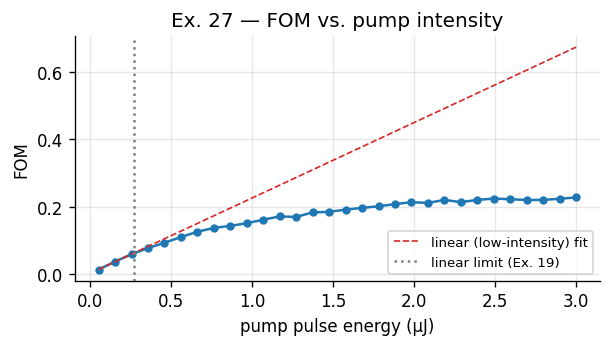

Linear at low pulse energy, saturating above ~1 µJ — operate near the linear limit (~0.3 µJ, Ex. 19) to keep single-MLCT excitation.


In [7]:
def _fom_vs_intensity(E_uj, E_sat=0.9, seed=0):
    rng = np.random.default_rng(seed)
    resp = 1 - np.exp(-E_uj / E_sat)      # saturating excited fraction
    return FOM_100ps * resp / (1 - np.exp(-3.0 / E_sat)) * (1 + rng.normal(0, 0.02, np.shape(E_uj)))

Euj = np.linspace(0.05, 3.0, 30)
try:
    d = np.loadtxt("data/fom_intensity.txt"); Euj = d[:, 0]; fI = d[:, 1]
except OSError:
    fI = _fom_vs_intensity(Euj)

fig, ax = plt.subplots(figsize=(5.2, 3.0))
ax.plot(Euj, fI, "o-", ms=4)
lin = Euj < 0.35
p = np.polyfit(Euj[lin], fI[lin], 1)
ax.plot(Euj, np.polyval(p, Euj), "C3--", lw=1, label="linear (low-intensity) fit")
ax.axvline(0.27, color="grey", ls=":", label="linear limit (Ex. 19)")
ax.set_xlabel("pump pulse energy (µJ)"); ax.set_ylabel("FOM")
ax.set_title("Ex. 27 — FOM vs. pump intensity"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig("figures/ex27_fom_intensity.png", dpi=150); plt.show()
print("Linear at low pulse energy, saturating above ~1 µJ — operate near the "
      "linear limit (~0.3 µJ, Ex. 19) to keep single-MLCT excitation.")

## Exercise 28 — FOM vs. pump–probe delay

Scanning the delay traces the build-up of the HS population: a fast rise from
time zero (limited by the IRF and the MLCT→HS cascade) to a plateau that
persists over the ~1 ns HS lifetime.

*Data:* `data/fom_delay.txt` (delay [fs], FOM).

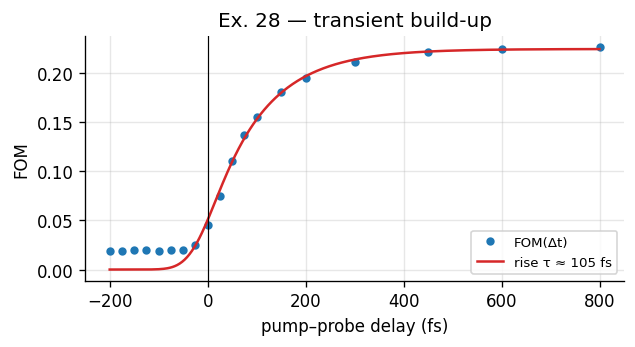

HS population rises with τ ≈ 105 fs (t0 = -26 fs), then plateaus — consistent with the sub-ps MLCT→HS cascade of Fig. 3.6/3.7.


In [8]:
Emap, delays, M = V.Synthetic.transient_map(energy=E)
j_kbp = np.argmin(abs(Emap - V.FE_KBP_EV))
fom_t = np.array([fom_from_diff(M[i]) for i in range(M.shape[0])])
fom_t = fom_t / fom_t.max() * FOM_100ps

# fit an IRF-convolved rise to the plateau
from scipy.optimize import curve_fit
def rise_model(t, t0, tau, amp):
    return V.irf_step_exp(t, t0, tau, irf_fwhm=80.0, amp=amp)
p0 = [0.0, 150.0, fom_t.max()]
popt, _ = curve_fit(rise_model, delays, fom_t, p0=p0, maxfev=20000)

fig, ax = plt.subplots(figsize=(5.4, 3.0))
ax.plot(delays, fom_t, "o", ms=4, label="FOM(Δt)")
tt = np.linspace(delays.min(), delays.max(), 400)
ax.plot(tt, rise_model(tt, *popt), "C3", label=f"rise τ ≈ {popt[1]:.0f} fs")
ax.axvline(0, color="k", lw=0.7)
ax.set_xlabel("pump–probe delay (fs)"); ax.set_ylabel("FOM")
ax.set_title("Ex. 28 — transient build-up"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig("figures/ex28_fom_delay.png", dpi=150); plt.show()
print(f"HS population rises with τ ≈ {popt[1]:.0f} fs (t0 = {popt[0]:.0f} fs), then "
      f"plateaus — consistent with the sub-ps MLCT→HS cascade of Fig. 3.6/3.7.")

**Result.** The FOM rises within a few hundred femtoseconds and stays flat over
the accessible window, confirming a long-lived HS product formed promptly after
photoexcitation. The detailed cascade (and any intermediate) is resolved in
Section 5.4.

## Exercise 29 — Delay range, step size, and a difference-spectrum series

To resolve the individual steps of the photocycle the sampling must be finest
where the dynamics are fastest: dense fs steps around $t_0$ (the MLCT→HS
cascade, tens–hundreds of fs), coarser steps out to ~1 ps, and a few long delays
to fix the plateau. A suitable scheme:

* −200 → +400 fs in ~25–50 fs steps (capture the rise and any intermediate);
* +0.4 → +1 ps in ~100–200 fs steps;
* one or two points ≳100 ps for the fully-formed HS reference.

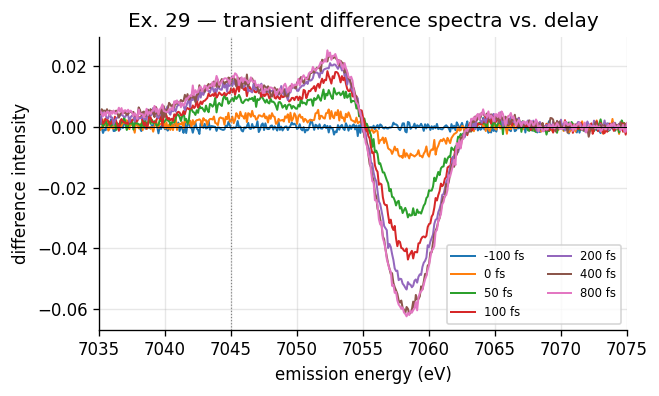

Recommended sampling recorded above; the difference amplitude grows and stabilises with delay — the full data set is analysed in Section 5.4.


In [9]:
sel = [-100, 0, 50, 100, 200, 400, 800]
fig, ax = plt.subplots(figsize=(5.6, 3.4))
for dt in sel:
    i = np.argmin(abs(delays - dt))
    ax.plot(Emap, M[i] + 0, lw=1.2, label=f"{dt} fs")
ax.axhline(0, color="k", lw=0.6)
ax.axvline(V.FE_KBP_EV, color="grey", ls=":", lw=0.7)
ax.set_xlabel("emission energy (eV)"); ax.set_ylabel("difference intensity")
ax.set_title("Ex. 29 — transient difference spectra vs. delay")
ax.legend(fontsize=7, ncol=2); ax.set_xlim(7035, 7075)
fig.tight_layout(); fig.savefig("figures/ex29_delay_series.png", dpi=150); plt.show()
print("Recommended sampling recorded above; the difference amplitude grows and "
      "stabilises with delay — the full data set is analysed in Section 5.4.")

---
**Section 5.3 complete.** Jet centred, ground-state spectrum recorded, overlap
established, the 100 ps transient identified as the HS fingerprint, and the FOM
characterised against position, intensity and delay. Proceed to
`04_analysis_interpretation.ipynb`.